In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def ucb(n_arms, true_means, n_steps, c):

    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)

    total_reward = 0

    rewards = []
    actions = []

    # Select each arm once
    for action in range(n_arms):

        reward = np.random.normal(true_means[action], 1)

        N[action] += 1
        Q[action] = reward

        total_reward += reward

        rewards.append(total_reward)
        actions.append(action)

    # Main UCB loop
    for step in range(n_arms, n_steps):

        ucb_values = Q + c * np.sqrt(np.log(step + 1) / N)

        best_actions = np.flatnonzero(ucb_values == ucb_values.max())
        action = np.random.choice(best_actions)

        reward = np.random.normal(true_means[action], 1)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

        total_reward += reward

        rewards.append(total_reward)
        actions.append(action)

    return total_reward, rewards, actions, Q, N

In [3]:
n_arms = 4

true_means = np.array([0.2, 0.9, 0.6, 0.4])

total_reward, rewards, actions, Q, N = ucb(
    n_arms,
    true_means,
    1000,
    c=2
)

print("Total Reward:", total_reward)
print("Estimated Rewards:", Q)
print("Selections:", N)

Total Reward: 731.99207087184
Estimated Rewards: [0.24013438 0.82986455 0.47846092 0.4725707 ]
Selections: [ 47. 755. 100.  98.]


In [4]:
c_values = [0.5, 1, 2, 4]

ucb_results = {}

for c in c_values:

    total_reward, rewards, actions, Q, N = ucb(
        n_arms=n_arms,
        true_means=true_means,
        n_steps=1000,
        c=c
    )

    ucb_results[c] = {
        "total_reward": total_reward,
        "rewards": rewards,
        "Q": Q,
        "N": N
    }

    print("=" * 60)
    print(f"c = {c}")
    print(f"Total Reward = {total_reward:.2f}")
    print(f"Estimated Rewards = {Q}")
    print(f"Selections = {N}")

c = 0.5
Total Reward = 908.28
Estimated Rewards = [-0.01320106  0.92164707  0.68006889 -0.01136812]
Selections = [  3. 959.  36.   2.]
c = 1
Total Reward = 875.88
Estimated Rewards = [0.35085037 0.9169242  0.652485   0.3925201 ]
Selections = [ 18. 885.  77.  20.]
c = 2
Total Reward = 726.79
Estimated Rewards = [0.3232467  0.82226276 0.3046774  0.43177079]
Selections = [ 61. 791.  57.  91.]
c = 4
Total Reward = 750.47
Estimated Rewards = [-0.16811087  0.93596638  0.53173151  0.57570932]
Selections = [ 50. 608. 161. 181.]


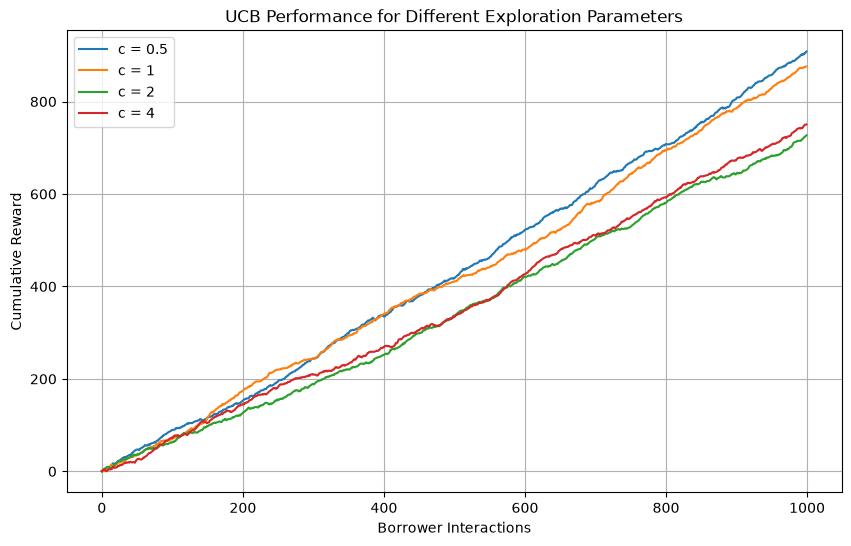

In [5]:
plt.figure(figsize=(10,6))

for c in c_values:
    plt.plot(ucb_results[c]["rewards"], label=f"c = {c}")

plt.title("UCB Performance for Different Exploration Parameters")
plt.xlabel("Borrower Interactions")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
print(f"{'c':<8}{'Total Reward':<18}{'Best Arm'}")

for c in c_values:

    total = ucb_results[c]["total_reward"]
    best_arm = np.argmax(ucb_results[c]["N"])

    print(f"{c:<8}{total:<18.2f}{best_arm}")

c       Total Reward      Best Arm
0.5     908.28            1
1       875.88            1
2       726.79            1
4       750.47            1


In [7]:
ucb_results

{0.5: {'total_reward': 908.2796827321209,
  'rewards': [1.013036152692263,
   2.6451730820094843,
   2.85092093475538,
   3.05759067630946,
   4.323856305720148,
   5.542948856256787,
   5.6677094806991395,
   5.343448527132472,
   5.4502098974951965,
   6.285667303779203,
   7.523184802196812,
   7.640487219840655,
   10.622340255638823,
   12.029418268979695,
   14.74002081099474,
   15.759494386870939,
   17.56879008978303,
   16.705458608217466,
   16.545361393491437,
   16.351587524109462,
   17.91116206190097,
   19.1128645570115,
   20.40272199935384,
   22.487232172496938,
   23.11096362135253,
   23.781823833126428,
   24.349409632940855,
   25.556351159281043,
   27.48805243641504,
   28.301741677494935,
   28.545819570433064,
   30.365779164185103,
   29.369401631226417,
   30.892162182090107,
   31.181584956474964,
   30.952178982314106,
   33.25705872430831,
   33.34875481445788,
   34.28597370371808,
   35.566449475567744,
   35.9407231163808,
   34.95672032117167,
   38.

In [8]:

best_c = max(ucb_results, key=lambda c: ucb_results[c]["total_reward"])
print()

print("Best c:", best_c)
print("Reward:", ucb_results[best_c]["total_reward"])


Best c: 0.5
Reward: 908.2796827321209


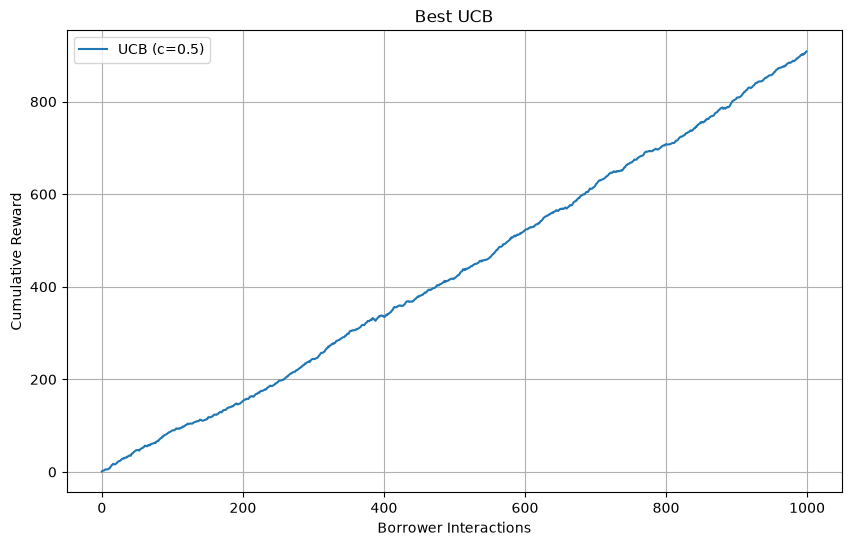

In [9]:
plt.figure(figsize=(10,6))



plt.plot(
    ucb_results[best_c]["rewards"],
    label=f"UCB (c={best_c})"
)

plt.title("Best UCB")
plt.xlabel("Borrower Interactions")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.grid(True)

plt.show()